<a href="https://colab.research.google.com/github/equinox-1092/Notes_Power_Bi/blob/master/SESI%C3%93N_3_intermedio.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

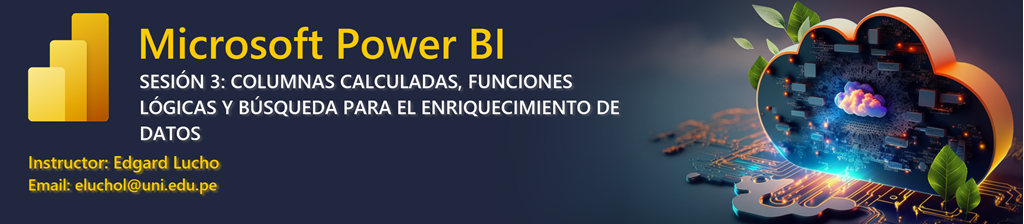

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Creación de la Tabla Calendario</font>**

</td>
</tr>
</table>

Una tabla calendario en Power BI es fundamental para el análisis de datos temporales.

>* **1. Facilita el Análisis Temporal**: Permite realizar análisis detallados a lo largo del tiempo, como comparaciones año a año, mes a mes y día a día.
>* **2. Relaciones entre Tablas**: La tabla calendario puede establecer relaciones con otras tablas en el modelo de datos. Esto ayuda a hacer un seguimiento de las métricas a lo largo del tiempo de manera efectiva.
>* **3. Creación de Períodos de Tiempo**: Puedes crear jerarquías de tiempo, como año, trimestre, mes y día, lo que simplifica la visualización y el filtrado de datos en informes.
>* **4. Manejo de Fechas Específicas**: Es posible agregar columnas personalizadas para días laborables, festivos, trimestres, etc., lo que permite un análisis más contextualizado.
>* **5. Facilitar Cálculos DAX**: Las tablas calendario permiten utilizar funciones DAX especializadas para cálculos relacionados con el tiempo, como acumulados, porcentajes de crecimiento, entre otros.
>* **6. Mejora en el Rendimiento**: Al tener un conjunto de fechas predefinido y estructurado, optimiza las consultas y el rendimiento del modelo de datos.

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">CALENDARAUTO()</font>**

</td>
</tr>
</table>

La función **CALENDARAUTO** en DAX (Data Analysis Expressions) de Power BI se utiliza para crear automáticamente una tabla de fechas en función de los datos de tu modelo.

**CALENDARAUTO** genera una tabla de calendario que abarca el rango de fechas que se encuentran en las columnas de tipo fecha de todas las tablas en el modelo. Esto significa que no necesitas especificar un rango de fechas manualmente; la función lo calcula automáticamente.

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Sintaxis</font>**

</td>
</tr>
</table>



```
CALENDARAUTO([AñoFiscal])
```



>* **[AñoFiscal]** (Opcional): Puedes especificar el mes que inicia el año fiscal. Por defecto, considera enero como el primer mes del año fiscal.

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Funcionalidad</font>**

</td>
</tr>
</table>

>* **Creación Automática**: Detecta automáticamente las fechas en tu modelo para determinar el rango mínimo y máximo de fechas.
>* **Sin Datos Manuales**: No necesitas preocuparte por definir manualmente las fechas de inicio y fin, lo que ahorra tiempo y reduce errores.
>* **Establecer el Año Fiscal**: Si tu negocio utiliza un año fiscal diferente al calendario normal, puedes especificar el mes que comienza el año fiscal, ajustando así el comportamiento de la tabla de calendario.

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Ejemplo de Uso</font>**

</td>
</tr>
</table>

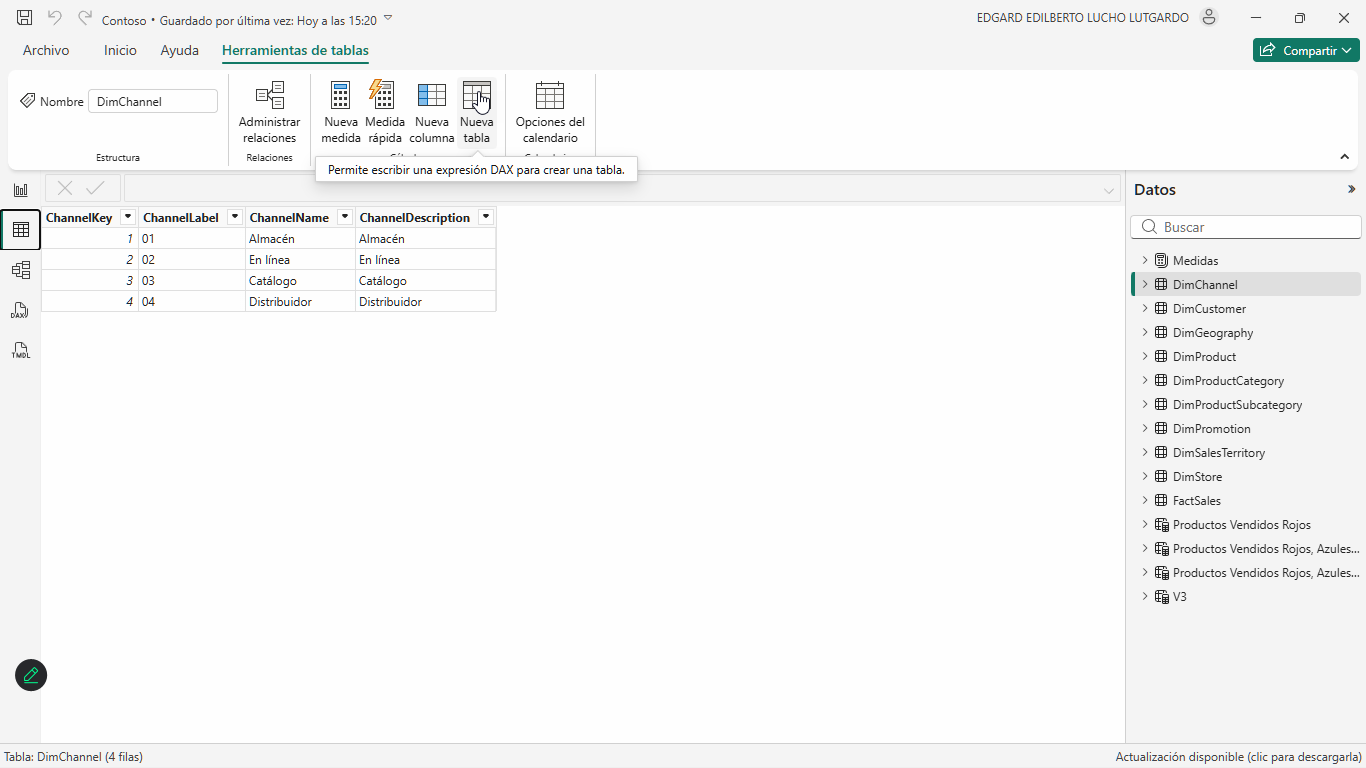



```
DimCalendario = CALENDARAUTO()
```





```
Año = YEAR([Date])
```





```
Semestre = IF(MONTH([Date])>6, "S-2", "S-1")
```





```
Trimestre = "T-"&QUARTER([Date])
```





```
Mes = FORMAT([Date], "mmmm")
```





```
MesAbr = FORMAT([Date], "mmm")
```



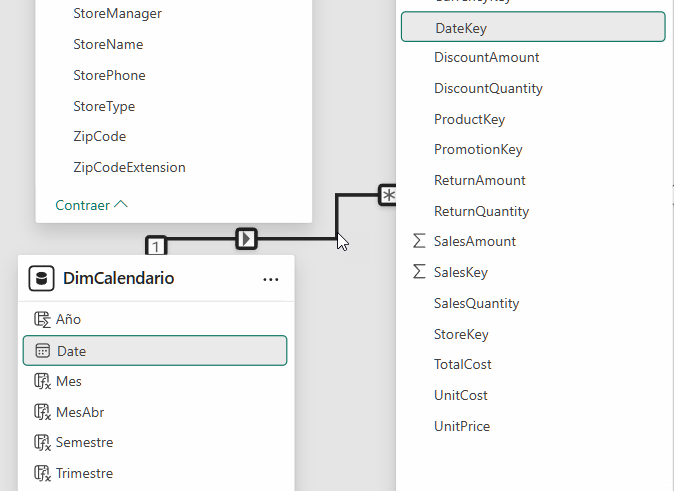

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">CALENDAR()</font>**

</td>
</tr>
</table>

La función CALENDAR() en DAX (Data Analysis Expressions) es utilizada para crear una tabla de fechas que abarca un rango específico de fechas definidas por el usuario.

Esta función es fundamental para realizar análisis temporal en Power BI y es una alternativa a CALENDARAUTO(), donde el usuario tiene control total sobre el rango de fechas.

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Sintaxis</font>**

</td>
</tr>
</table>



```
CALENDAR(FechaInicial, FechaFinal)
```



>* **FechaInicial**: La fecha de inicio del rango. Puede ser una fecha literal entre comillas, una referencia a una celda que contenga una fecha, o una función que retorne una fecha.
>* **FechaFinal**: La fecha final del rango. Al igual que FechaInicial, puede ser una fecha literal, una referencia, o el resultado de una función.

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Ejemplo de Uso</font>**

</td>
</tr>
</table>



```
DimCalendario =
VAR FechaIni = MIN(FactSales[DateKey])
VAR FechaFin = MAX(FactSales[DateKey])
RETURN
ADDCOLUMNS
(
    CALENDAR
    (
        FechaIni,
        FechaFin
    ),
    "Año", YEAR([Date]),
    "Semestre", IF(MONTH([Date])>6, "S-2", "S-1"),
    "PeriodoXSem", "PS-" &  INT(DATEDIFF(FechaIni, [Date], MONTH) / 6) + 1,
    "PeriodoXSemNum", INT(DATEDIFF(FechaIni, [Date], MONTH) / 6) + 1,
    "Trimestre", "T-"&QUARTER([Date]),
    "PeriodoXTrim", "PT-"&DATEDIFF(FechaIni, [Date], QUARTER) + 1,
    "PeriodoXTrimNum", DATEDIFF(FechaIni, [Date], QUARTER) + 1,
    "Mes", FORMAT([Date], "mmmm"),
    "MesAbr", FORMAT([Date], "mmm"),
    "MesNum", MONTH([Date]),
    "PeriodoXMes", "PM-"&DATEDIFF(FechaIni, [Date], MONTH) + 1,
    "PeriodoXMesNum", DATEDIFF(FechaIni, [Date], MONTH) + 1,
    "SemAño", WEEKNUM([Date]),
    "PeriodoXSemana", "PSem-"&DATEDIFF(FechaIni, [Date], WEEK) + 1,
    "PeriodoXSemanaNum", DATEDIFF(FechaIni, [Date], WEEK) + 1,
    "Día", FORMAT([Date], "dddd"),
    "DíaAbr", FORMAT([Date], "ddd"),
    "DíaNum", WEEKDAY([Date]),
    "DíaMes", DAY([Date]),
    "PeriodoXDía", "PD-"&DATEDIFF(FechaIni, [Date], DAY) + 1,
    "PeriodoXDíaNum", DATEDIFF(FechaIni, [Date], DAY) + 1
)
```



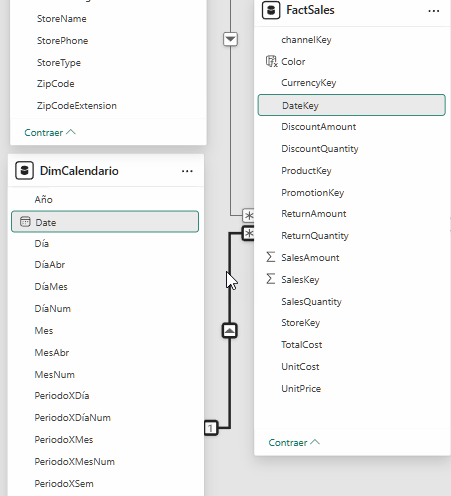

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Costos</font>**

</td>
</tr>
</table>



```
Costos SUM = SUM(FactSales[TotalCost])
```





```
Costos SUMX =
SUMX
(
    FactSales,
    FactSales[UnitCost]
    *
    (
        FactSales[SalesQuantity] - FactSales[ReturnQuantity]
    )
)
```



<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">Ventas</font>**

</td>
</tr>
</table>



```
Ventas SUM = SUM(FactSales[SalesAmount])
```





```
Ventas SUMX =
SUMX
(
    FactSales,
    (FactSales[SalesQuantity])
    *
    FactSales[UnitPrice]
    -
    FactSales[DiscountAmount]
)
```





```
Ventas SUMX AVANZADO =
SUMX
(
    FactSales,
    (FactSales[SalesQuantity])
    *
    FactSales[UnitPrice]
    *
    (
        1
        -
        IF
        (
            // Condición
                FactSales[DateKey] >= RELATED(DimPromotion[StartDate])
            &&
                FactSales[DateKey] <= RELATED(DimPromotion[EndDate])
            &&
                FactSales[SalesQuantity] >= RELATED(DimPromotion[MinQuantity])
            &&
                FactSales[SalesQuantity] <= COALESCE(RELATED(DimPromotion[MaxQuantity]), 999999),
            // Verdadera
            RELATED(DimPromotion[DiscountPercent]),
            // Falsa
            0
        )
    )
)
```



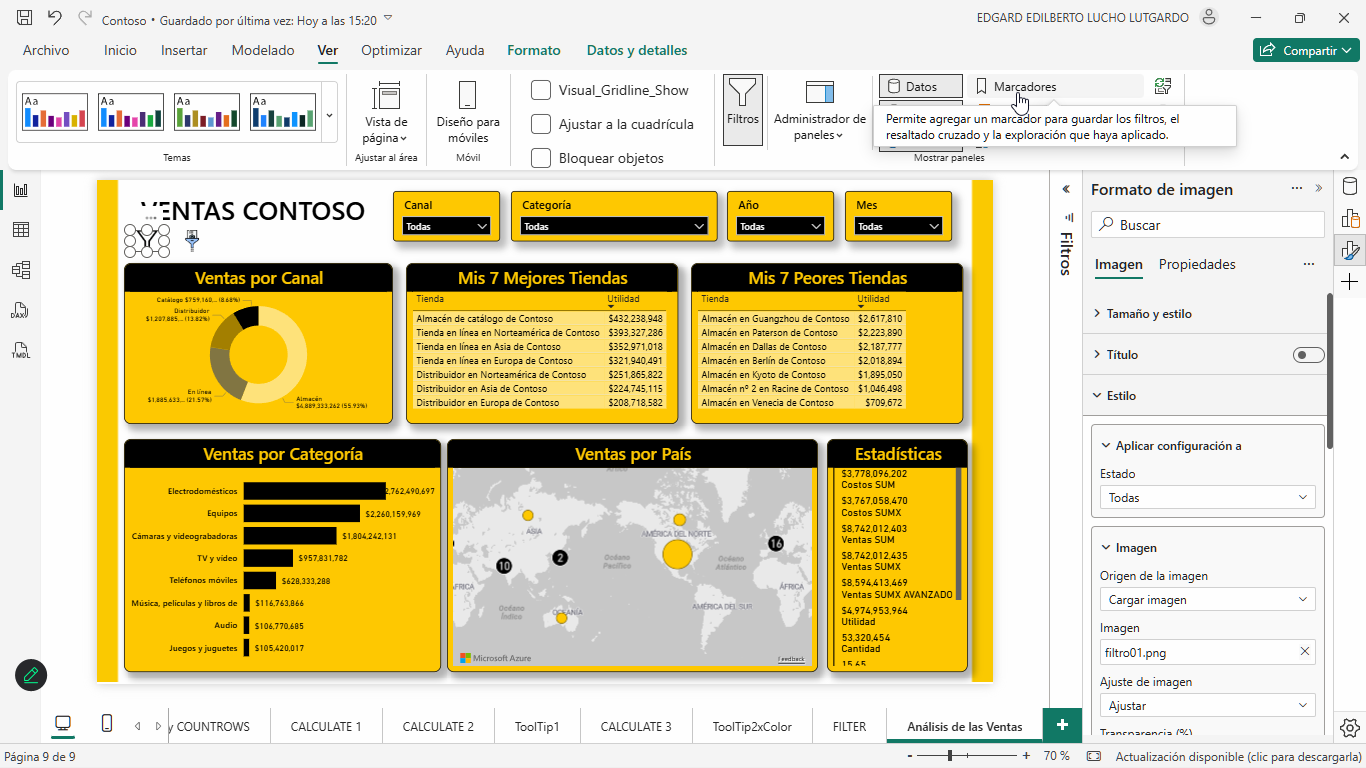

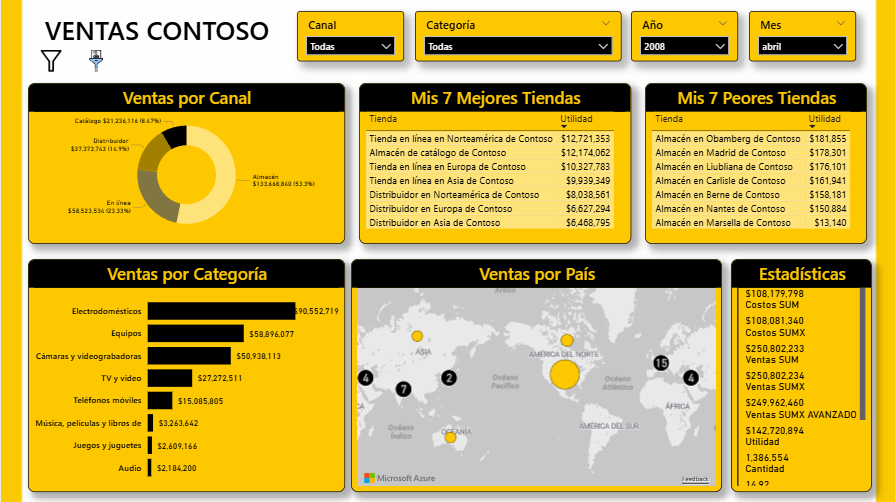

<table border=1 width='99%'>
<tr>
<td bgcolor='#4a235a'>

# **<font color="#FFFFFF">SWITCH</font>**

</td>
</tr>
</table>

La función **SWITCH** en DAX es una poderosa herramienta que te permite evaluar una expresión y devolver un valor específico basado en la coincidencia con diferentes condiciones.

Esta función es especialmente útil cuando necesitas evaluar múltiples condiciones en lugar de anidar múltiples IF.

<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Sintaxis</font>**

</td>
</tr>
</table>



```
SWITCH
(
    <Expresión>,
    <Valor1>, <Resulatdo1>,
    <Valor2>, <Resulatdo2>,
    <Valor3>, <Resulatdo3>,
    ...,
    <ValorN>, <ResulatdoN>,
    <Resultado por defecto>
)
```



<table width='99%'>
<tr>
<td bgcolor='#FF6600'>

## **<font color="#FFFFFF">Ejemplo de Uso</font>**

</td>
</tr>
</table>



```
Segmentación =
SWITCH
(
    TRUE(),
    FactSales[SalesQuantity]<=20, "Venta por menor",
    FactSales[SalesQuantity]<=50, "Venta medianas",
    FactSales[SalesQuantity]>50, "Venta por mayor",
    "Otros"
)
```

